## We are going 3D


In [1]:
from image_processing import *
import cv2
import numpy as np

# Load and convert images to grayscale if not already
img1 = cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('../34759_final_project_rect/seq_01/image_03/data/000000.png', cv2.IMREAD_GRAYSCALE)
# Load the color image and apply the mask to get colors for valid points
color_img = cv2.cvtColor(cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png'), cv2.COLOR_BGR2RGB)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Load calibration file and parse it
calibration = parse_calibration_data("../34759_final_project_rect/calib_cam_to_cam.txt")

In [3]:
P_left = calibration["P_rect_02"]
P_right = calibration["P_rect_03"]

print(P_left)
print(P_right)

Q = calculate_q_matrix(P_left, P_right)
print(Q)

[[ 7.070493e+02  0.000000e+00  6.040814e+02  4.575831e+01]
 [ 0.000000e+00  7.070493e+02  1.805066e+02 -3.454157e-01]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  4.981016e-03]]
[[ 7.070493e+02  0.000000e+00  6.040814e+02 -3.341081e+02]
 [ 0.000000e+00  7.070493e+02  1.805066e+02  2.330660e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  3.201153e-03]]
[[   1.            0.            0.         -604.0814    ]
 [   0.            1.            0.         -180.5066    ]
 [   0.            0.            0.         -707.0493    ]
 [   0.            0.           -2.11622915    0.        ]]


In [59]:
from matplotlib import pyplot as plt
def plot_disparity_map(disp_map):
    """
    Plot the disparity map using Matplotlib.

    Parameters:
    - disp_map: Disparity map generated from compute_disparity_map function.
    """
    # Set the minimum and maximum disparity values for visualization
    plt.figure(figsize=(10, 7))
    plt.imshow(disp_map, cmap='plasma')
    plt.colorbar(label='Disparity Value')
    plt.title("Disparity Map")
    plt.xlabel("X-axis (pixels)")
    plt.ylabel("Y-axis (pixels)")
    plt.show()

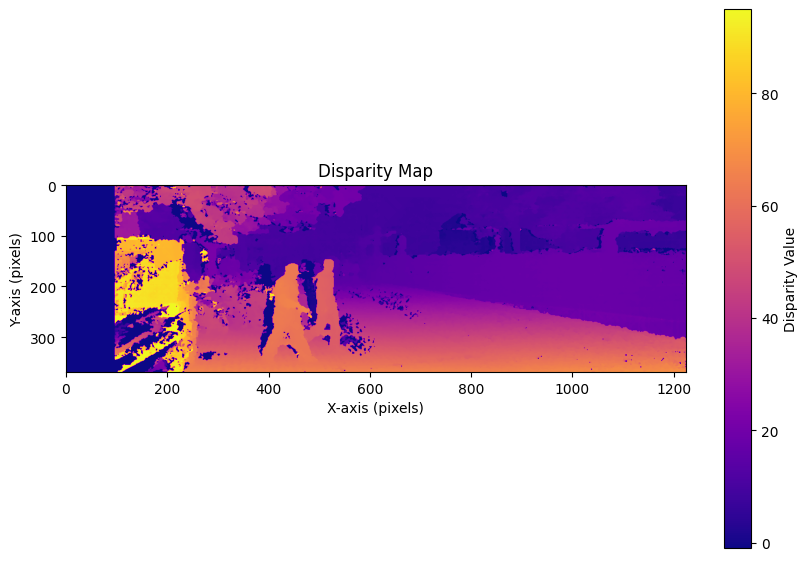

Diparity map range: -1.0 95.0


In [ ]:
disp_map = compute_disparity_map(img1, img2,min_disparity=0, num_disparities=6*16, block_size=2)

plot_disparity_map(disp_map)

print(f'Disparity map range: {disp_map.min()} {disp_map.max()}')

In [ ]:


points, colors = generate_point_cloud(disp_map, Q, color_image=color_img, max_z=20)
print(points)
print(points[:,2].max())
print(points[:,2].min())

[[10.611628   3.770004  14.767209 ]
 [10.590742   3.770004  14.767209 ]
 [14.220772   5.092319  19.946753 ]
 ...
 [-4.1547494 -1.2735715  4.7772384]
 [-4.1393113 -1.2667792  4.7517595]
 [-4.164541  -1.2724344  4.772973 ]]
19.946753
3.5169275


In [64]:


# Visualize
visualize_point_cloud(points, colors)



## 3D-point occlusion

In [7]:
from image_processing import *
import cv2

# Load and convert images to grayscale if not already
rect_img1 = cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png', cv2.IMREAD_GRAYSCALE)
rect_img2 = cv2.imread('../34759_final_project_rect/seq_01/image_03/data/000000.png', cv2.IMREAD_GRAYSCALE)
# Load the color image and apply the mask to get colors for valid points
color_img = cv2.cvtColor(cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png'), cv2.COLOR_BGR2RGB)

In [8]:
# Load calibration file and parse it
calibration = parse_calibration_data("../34759_final_project_rect/calib_cam_to_cam.txt")
P_left = calibration["P_rect_02"]
P_right = calibration["P_rect_03"]

In [9]:
bb_path = r"../bb_000000.txt"
bounding_boxes_dict = extract_bbox_from_txt(bb_path)
bounding_boxes = bounding_boxes_dict["bbox"]
bbox_mask = create_bbox_mask(rect_img1.shape, bounding_boxes)

In [11]:
point_cloud = RectImg2PC(rect_img1, rect_img2, P_left, P_right, color_img=color_img, mask=bbox_mask)

In [12]:
o3d.visualization.draw_geometries([point_cloud])
o3d.io.write_point_cloud('filtered_point_cloud.ply', point_cloud)

True

# Same but segmentation instead of Bbox

In [13]:
from image_processing import *
import cv2

# Load and convert images to grayscale if not already
rect_img1 = cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png', cv2.IMREAD_GRAYSCALE)
rect_img2 = cv2.imread('../34759_final_project_rect/seq_01/image_03/data/000000.png', cv2.IMREAD_GRAYSCALE)
# Load the color image and apply the mask to get colors for valid points
color_img = cv2.cvtColor(cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png'), cv2.COLOR_BGR2RGB)


In [14]:
# Load calibration file and parse it
calibration = parse_calibration_data("../34759_final_project_rect/calib_cam_to_cam.txt")
P_left = calibration["P_rect_02"]
P_right = calibration["P_rect_03"]

In [15]:
seg_path = r"../points.json"
seg_mask = create_seg_mask(file_path=seg_path, image_shape=rect_img1.shape, target_class_labels=None)


In [16]:
point_cloud = RectImg2PC(rect_img1, rect_img2, P_left, P_right, max_z=20, color_img=color_img, mask=seg_mask)

In [17]:
o3d.visualization.draw_geometries([point_cloud])
o3d.io.write_point_cloud('filtered_point_cloud.ply', point_cloud)

True

# Hungarian algorithm


In [1]:
from tracking import *
from image_processing import *
from ultralytics import YOLO
from pointcloud_clustering import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load and convert images to grayscale if not already
img_left1 = r'../34759_final_project_rect/seq_01/image_02/data/000000.png'
img_left2 = r'../34759_final_project_rect/seq_01/image_02/data/000001.png'
model = YOLO(r"../yolo11x-seg.pt")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
prev_detections = cluster_from_stereo(model=model, img_left=img_left1, save_results=True, visualize = True)


image 1/1 c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\Perception-for-Autonomous-systems-DTU-2024\..\34759_final_project_rect\seq_01\image_02\data\000000.png: 224x640 2 persons, 407.0ms
Speed: 2.0ms preprocess, 407.0ms inference, 2.0ms postprocess per image at shape (1, 3, 224, 640)
Detection 0: X max=499, Y max=353
Detection 1: X max=553, Y max=330
Point cloud saved to c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\results\000000_segmented_point_cloud.ply
Best parameters: eps=0.3, min_samples=1000
Centroid 0: Position=[     1.2666    -0.62547      5.3264], Class=0
Centroid 1: Position=[    0.78346    -0.54836      6.1065], Class=0


In [3]:
curr_detections = cluster_from_stereo(model=model, img_left=img_left2, save_results=True, visualize = True)


image 1/1 c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\Perception-for-Autonomous-systems-DTU-2024\..\34759_final_project_rect\seq_01\image_02\data\000001.png: 224x640 2 persons, 883.1ms
Speed: 3.0ms preprocess, 883.1ms inference, 4.0ms postprocess per image at shape (1, 3, 224, 640)
Detection 0: X max=493, Y max=363
Detection 1: X max=549, Y max=330
Point cloud saved to c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\results\000001_segmented_point_cloud.ply
Best parameters: eps=0.3, min_samples=1000
Centroid 0: Position=[     0.6988    -0.53836      6.0668], Class=0
Centroid 1: Position=[     1.1422    -0.61671      5.2826], Class=0


In [4]:
matches, unmatched_previous, unmatched_current = assign_centroids(prev_detections, curr_detections)

In [5]:
def visualize_assignments(previous_detections, current_detections, matches):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot previous detections
    prev_centroids = np.array([det.centroid for det in previous_detections])
    ax.scatter(prev_centroids[:, 0], prev_centroids[:, 1], prev_centroids[:, 2],
               c='r', label='Previous Detections')

    # Plot current detections
    curr_centroids = np.array([det.centroid for det in current_detections])
    ax.scatter(curr_centroids[:, 0], curr_centroids[:, 1], curr_centroids[:, 2],
               c='b', label='Current Detections')

    # Draw lines between matched detections
    for prev_idx, curr_idx in matches:
        x_values = [previous_detections[prev_idx].centroid[0],
                    current_detections[curr_idx].centroid[0]]
        y_values = [previous_detections[prev_idx].centroid[1],
                    current_detections[curr_idx].centroid[1]]
        z_values = [previous_detections[prev_idx].centroid[2],
                    current_detections[curr_idx].centroid[2]]
        ax.plot(x_values, y_values, z_values, c='g')

    ax.legend()
    plt.show()

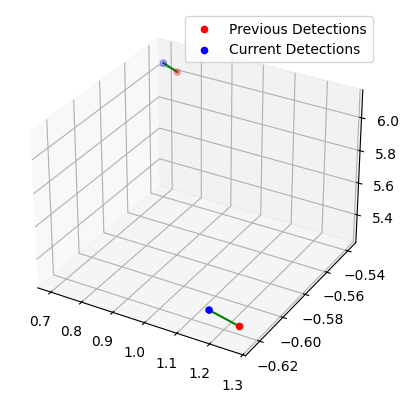

In [6]:
# After assigning centroids, call the visualization function
visualize_assignments(prev_detections, curr_detections, matches)

# Hungarian full run

In [1]:
from tracking import *
from image_processing import *
from ultralytics import YOLO
from pointcloud_clustering import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
def visualize_tracked_objects(tracked_objects):
    """
    Plots the history of tracked objects in 3D space, differentiating classes.

    Parameters:
    - tracked_objects: A list of TrackedObject instances.
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Define colors for different classes
    class_colors = {
        0: 'r',  # Example class labels and colors
        1: 'g',
        2: 'b'
    }

    for obj in tracked_objects:
        history = np.array(obj.history)
        if history.size == 0:
            continue
        color = class_colors.get(obj.class_label, 'k')  # Default to black if class not specified
        ax.plot(history[:, 0], history[:, 1], history[:, 2], color=color, label=f'Object {obj.id}')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # To avoid duplicate labels in the legend
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys())
    plt.show()


In [3]:
# Load and convert images to grayscale if not already
img_left1 = r'../34759_final_project_rect/seq_01/image_02/data/000000.png'
img_left2 = r'../34759_final_project_rect/seq_01/image_02/data/000001.png'
model = YOLO(r"../yolo11x-seg.pt")
video_frames = [img_left1,img_left2]

In [4]:
# Main tracking loop
tracked_objects = []
next_object_id = 0

print(f"Number of frames: {len(video_frames)}")

for frame_idx, frame in enumerate(video_frames):
    print(f"\nProcessing frame {frame_idx + 1}/{len(video_frames)}")
    
    # Get current detections directly as a list of Detection objects
    current_detections = cluster_from_stereo(model, frame, conf= 0.7, save_results= False, visualize = False)
    print(f"Number of current detections: {len(current_detections)}")
    
    # Predict tracked object positions
    for obj in tracked_objects:
        obj.predict()
    
    # Assign detections to tracked objects
    previous_detections = [Detection(obj.centroid, obj.class_label) for obj in tracked_objects]
    matches, unmatched_prev, unmatched_curr = assign_centroids(
        previous_detections,
        current_detections,
    )
    print(f"Matches: {matches}")
    print(f"Unmatched previous detections: {unmatched_prev}")
    print(f"Unmatched current detections: {unmatched_curr}")
    
    # Update matched tracked objects
    for prev_idx, curr_idx in matches:
        tracked_objects[prev_idx].update(current_detections[curr_idx])
    
    # Create new tracked objects for unmatched detections
    for idx in unmatched_curr:
        obj = TrackedObject(current_detections[idx], next_object_id)
        tracked_objects.append(obj)
        next_object_id += 1
    
    # Remove lost tracked objects based on your criteria
    max_age = 5
    tracked_objects = [obj for obj in tracked_objects if obj.time_since_update <= max_age]
    
    # Print tracked objects info
    print(f"Number of tracked objects: {len(tracked_objects)}")
    for obj in tracked_objects:
        print(f"Object ID: {obj.id}, History Length: {len(obj.history)}")
    
    # Visualize the tracked objects
    try:
        visualize_tracked_objects(tracked_objects)
    except Exception as e:
        print(f"An error occurred during visualization: {e}")


Number of frames: 2

Processing frame 1/2

image 1/1 c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\Perception-for-Autonomous-systems-DTU-2024\..\34759_final_project_rect\seq_01\image_02\data\000000.png: 224x640 2 persons, 1 truck, 402.0ms
Speed: 1.0ms preprocess, 402.0ms inference, 2.0ms postprocess per image at shape (1, 3, 224, 640)
Left image path: ..\34759_final_project_rect\seq_01\image_02\data\000000.png
Right image path: ..\34759_final_project_rect\seq_01\image_03\data\000000.png


UnboundLocalError: local variable 'results_directory_path' referenced before assignment